# Synthetic 2D Data: Linear Support Vector Machine Geometry

## Project Overview

This notebook explores the geometry and internal computations of a linear Support Vector Machine (SVM) in two dimensions.

The experiments make the margin, support vectors, regularization parameter \(C\), separating hyperplane, dual coefficients, prediction scores, and recovered weight vector directly observable.

### Technical Coverage

- linear SVM classification
- support vectors
- separating hyperplane visualization
- linearly separable and overlapping classes
- regularization parameter \(C\)
- margin/error tradeoff
- confusion matrices
- support-vector counts
- dual coefficients
- manual decision-score reconstruction
- manual prediction thresholding
- recovery of the primal weight vector

## 1. Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix


## 2. SVM Visualization Utility

The plotting function displays positive and negative training observations. When a fitted linear SVM is supplied, the support vectors are marked with stars and the separating line is reconstructed from the learned coefficient vector and intercept.

In [2]:
def plot_svm_data(X, y, model=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    pos_class = y == 1
    neg_class = y == 0

    ax.plot(X[pos_class, 0], X[pos_class, 1], '.r')
    ax.plot(X[neg_class, 0], X[neg_class, 1], '.b')

    if model is not None:
        svs = model.support_
        pos_sv = svs[y[svs] == 1]
        neg_sv = svs[y[svs] == 0]

        ax.plot(X[pos_sv, 0], X[pos_sv, 1], '*r')
        ax.plot(X[neg_sv, 0], X[neg_sv, 1], '*b')

        W = model.coef_
        b = model.intercept_

        x1 = np.array([np.min(X[:, 0]), np.max(X[:, 0])])
        x2 = (-W[0, 0] * x1 - b) / W[0, 1]

        plt.plot(x1, x2)

    ax.axis('equal')
    plt.show()


## 3. Linearly Separable Synthetic Dataset

A reproducible two-dimensional dataset is generated from points sampled inside a unit disk. One class remains centered near the origin, while the other is shifted by `[1, 2]`, producing linearly separable groups.

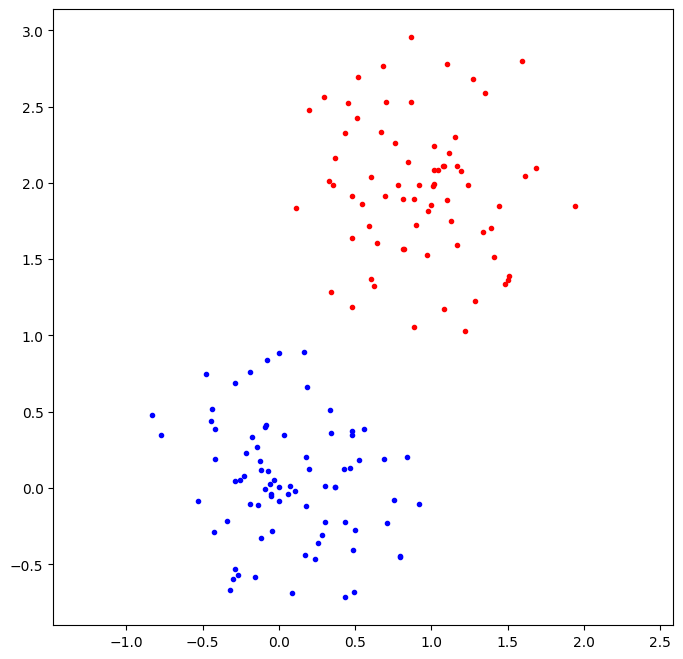

In [3]:
np.random.seed(5361)
n = 150
r = np.random.random(size = (n,1))
t = np.random.random(size = (n,1))*2*np.pi
X = np.hstack((r*np.sin(t),r*np.cos(t)))
y = np.int32(np.random.random(size = (n,))>0.5)
X[y==1] += np.array([1,2])
plot_svm_data(X,y)

## 4. Default Linear SVM

The first model uses a linear kernel with the default `C=1.0`. Because the generated groups are linearly separable, the fitted classifier reaches perfect training accuracy.

Accuracy 1.0
[[79  0]
 [ 0 71]]


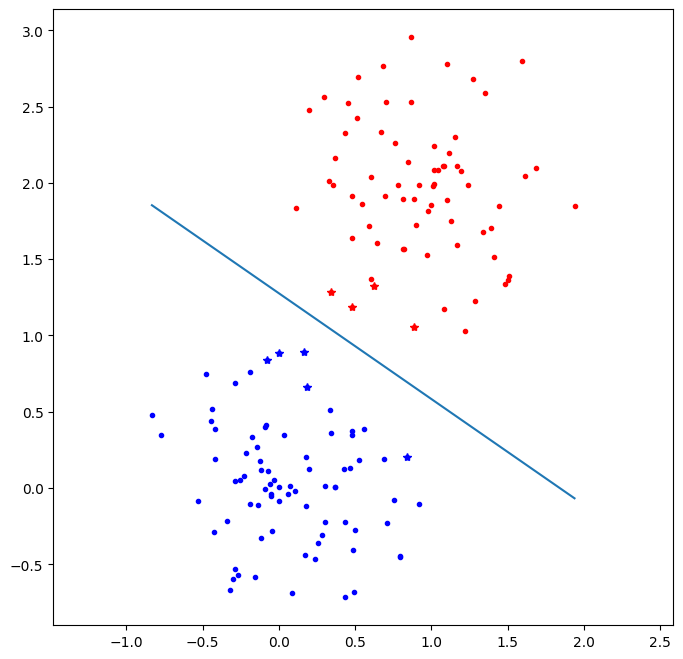

In [4]:
model = SVC(kernel='linear')
model.fit(X, y)
pred = model.predict(X)
accuracy = accuracy_score(y, pred)
print(f'Accuracy {accuracy:.4}')
print(confusion_matrix(y, pred))
plot_svm_data(X,y,model)

### Number of Support Vectors

In [5]:
print('Support vectors selected:',len(model.support_))

Support vectors selected: 9


## 5. Effect of the Regularization Parameter \(C\)

For this separable dataset, changing \(C\) does not change the training accuracy, but it changes how many observations lie on or inside the effective margin.

A larger \(C\) places a larger penalty on margin violations and tends to produce a narrower margin with fewer support vectors.

### `C = 10`

Accuracy 1.0
[[79  0]
 [ 0 71]]


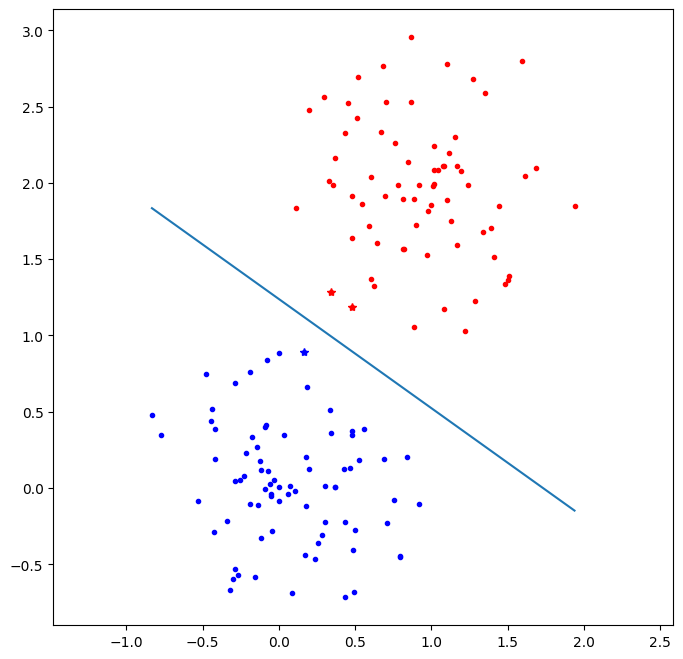

Support vectors selected: 3


In [6]:
model = SVC(kernel='linear', C=10)
model.fit(X, y)
pred = model.predict(X)
accuracy = accuracy_score(y, pred)
print(f'Accuracy {accuracy:.4}')
print(confusion_matrix(y, pred))
plot_svm_data(X,y,model)
print('Support vectors selected:',len(model.support_))

With `C=10`, the model uses exactly three support vectors, which is sufficient to define the maximum-margin separator in this two-dimensional example.

### `C = 100`

Accuracy 1.0
[[79  0]
 [ 0 71]]


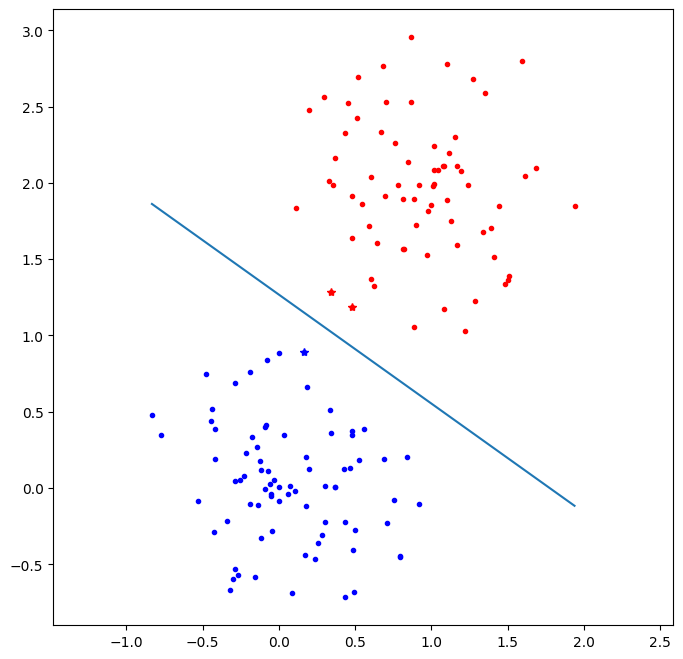

Support vectors selected: 3


In [7]:
model = SVC(kernel='linear', C=100)
model.fit(X, y)
pred = model.predict(X)
accuracy = accuracy_score(y, pred)
print(f'Accuracy {accuracy:.4}')
print(confusion_matrix(y, pred))
plot_svm_data(X,y,model)
print('Support vectors selected:',len(model.support_))

Increasing `C` from 10 to 100 leaves the learned classification behavior and support-vector count unchanged for this dataset.

### `C = 0.1`

Accuracy 1.0
[[79  0]
 [ 0 71]]


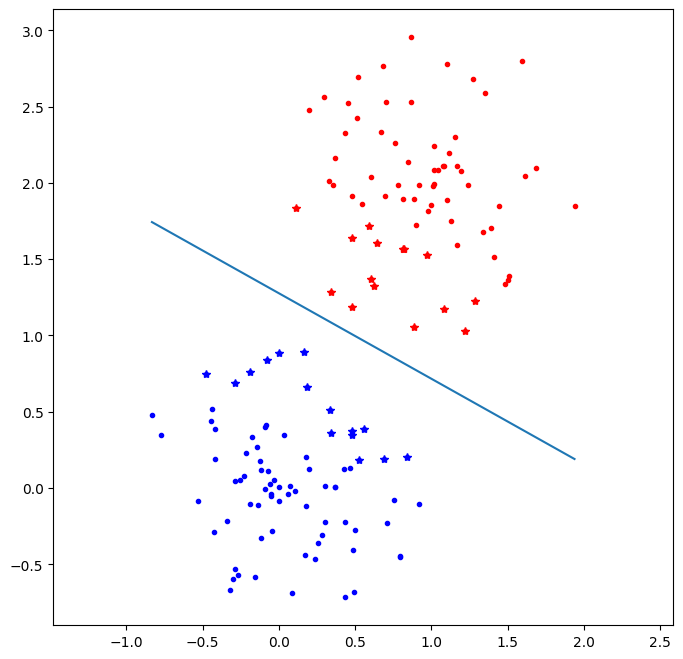

Support vectors selected: 30


In [8]:
model = SVC(kernel='linear', C=0.1)
model.fit(X, y)
pred = model.predict(X)
accuracy = accuracy_score(y, pred)
print(f'Accuracy {accuracy:.4}')
print(confusion_matrix(y, pred))
plot_svm_data(X,y,model)
print('Support vectors selected:',len(model.support_))

Reducing `C` increases the number of selected support vectors while preserving perfect accuracy on the separable training data.

## 6. Full `C` Sweep on a Second Separable Sample

A new sample from the same class-generating process is evaluated at `C = 0.01, 0.1, 1, 10, 100`.

Kernel = linear, C = 0.01, Accuracy: 1.0000
Confusion matrix
[[79  0]
 [ 0 71]]
Support vectors selected: 90


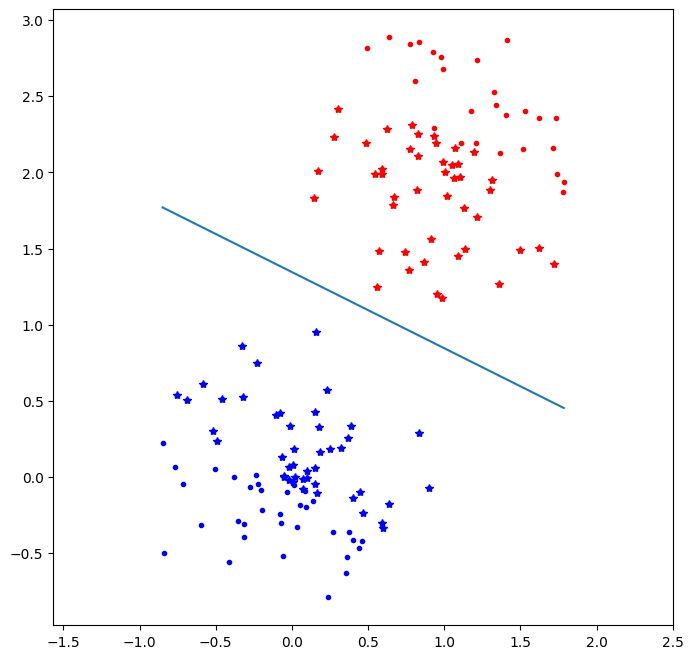

Kernel = linear, C = 0.10, Accuracy: 1.0000
Confusion matrix
[[79  0]
 [ 0 71]]
Support vectors selected: 24


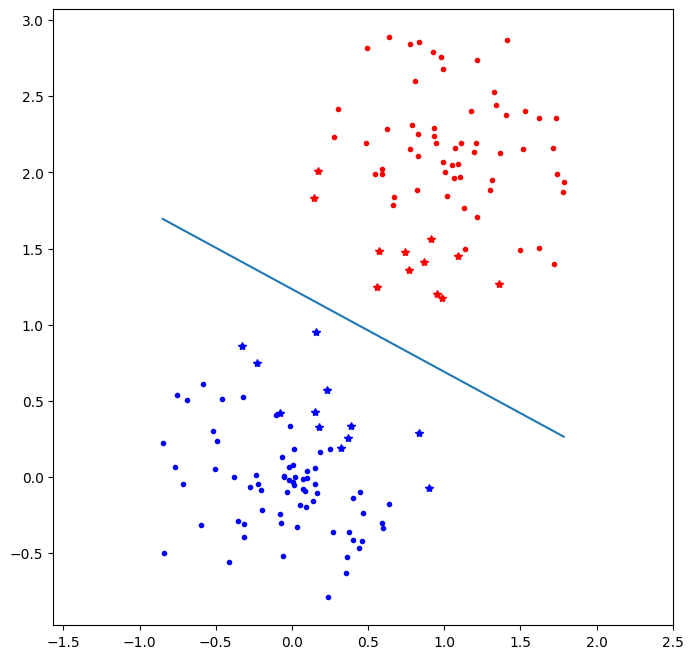

Kernel = linear, C = 1.00, Accuracy: 1.0000
Confusion matrix
[[79  0]
 [ 0 71]]
Support vectors selected: 6


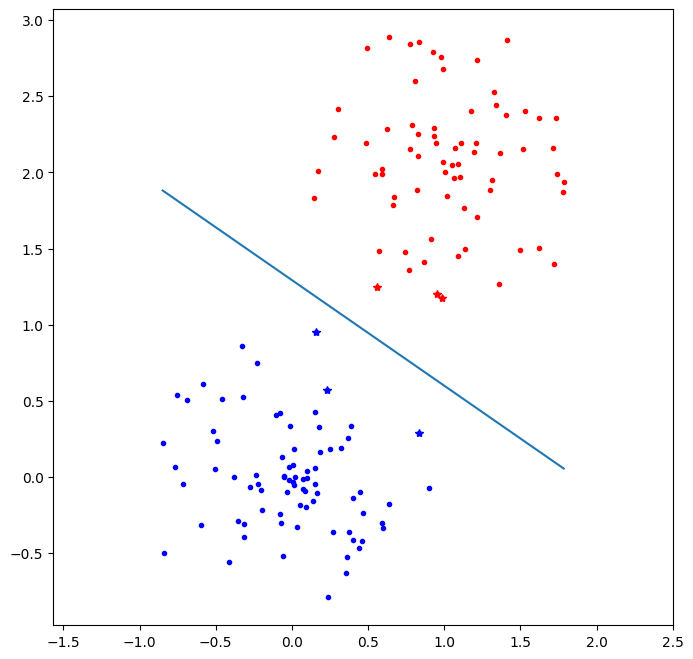

Kernel = linear, C = 10.00, Accuracy: 1.0000
Confusion matrix
[[79  0]
 [ 0 71]]
Support vectors selected: 3


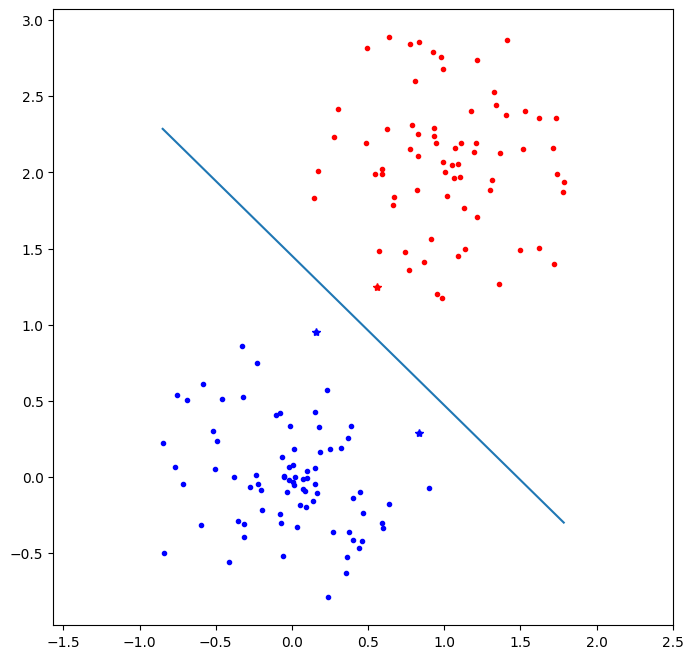

Kernel = linear, C = 100.00, Accuracy: 1.0000
Confusion matrix
[[79  0]
 [ 0 71]]
Support vectors selected: 3


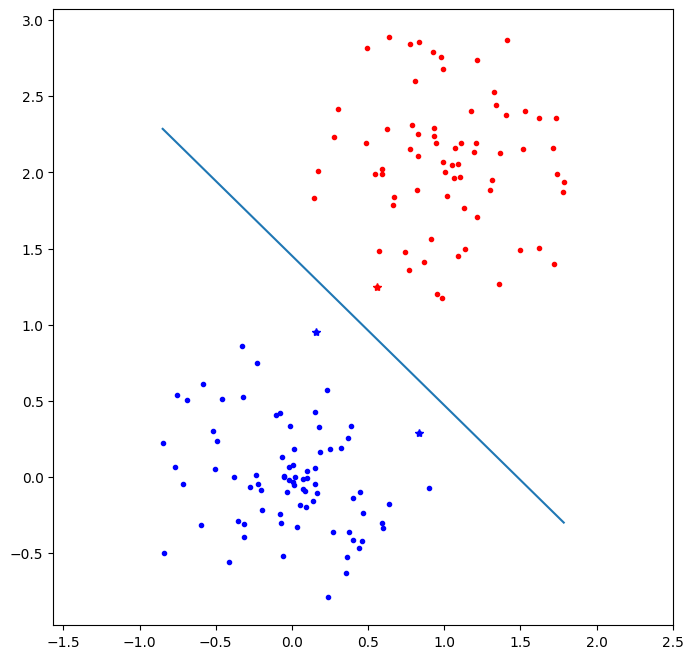

In [9]:
n = 150
r = np.random.random(size = (n,1))
t = np.random.random(size = (n,1))*2*np.pi
X = np.hstack((r*np.sin(t),r*np.cos(t)))
y = np.int32(np.random.random(size = (n,))>0.5)
X[y==1] += np.array([1,2])

C = [0.01, 0.1, 1.0, 10.0, 100.0]
kernel ='linear'
for c in C:
  model = SVC(C=c, kernel='linear')
  model.fit(X, y)
  pred = model.predict(X)
  accuracy = accuracy_score(y, pred)
  print('Kernel = {}, C = {:3.2f}, Accuracy: {:6.4f}'.format(kernel,c,accuracy))
  print('Confusion matrix')
  print(confusion_matrix(y, pred))
  print('Support vectors selected:',len(model.support_))
  plot_svm_data(X,y,model)

### Saved Results

| C | Accuracy | Support Vectors |
|---:|---:|---:|
| 0.01 | 1.0000 | 90 |
| 0.10 | 1.0000 | 24 |
| 1.00 | 1.0000 | 6 |
| 10.00 | 1.0000 | 3 |
| 100.00 | 1.0000 | 3 |

The accuracy remains perfect across the sweep, while the support-vector count decreases sharply as `C` increases.

## 7. Overlapping Classes

The positive class is now shifted by `[1, 1]` instead of `[1, 2]`, producing overlap between the two classes. The same `C` sweep shows how the margin/error tradeoff behaves when perfect separation is impossible.

Kernel = linear, C = 0.01, Accuracy: 0.9600
Confusion matrix
[[62  5]
 [ 1 82]]
Support vectors selected: 132


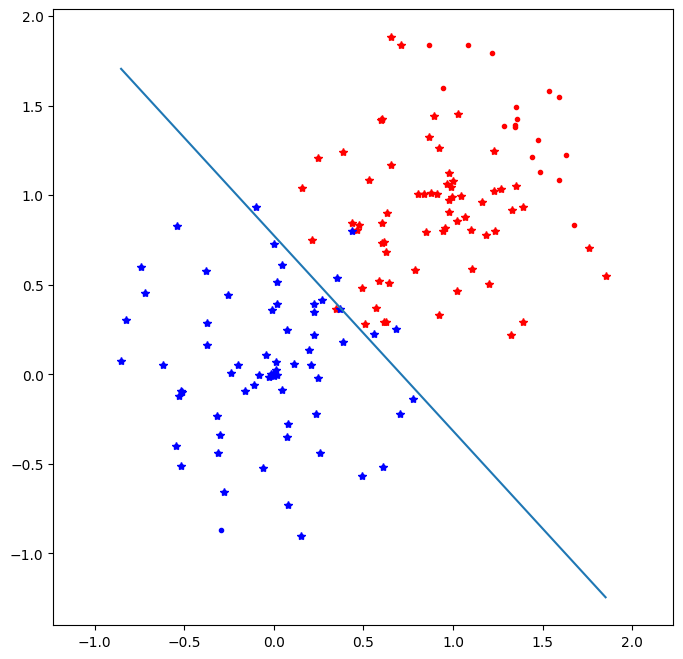

Kernel = linear, C = 0.10, Accuracy: 0.9667
Confusion matrix
[[65  2]
 [ 3 80]]
Support vectors selected: 58


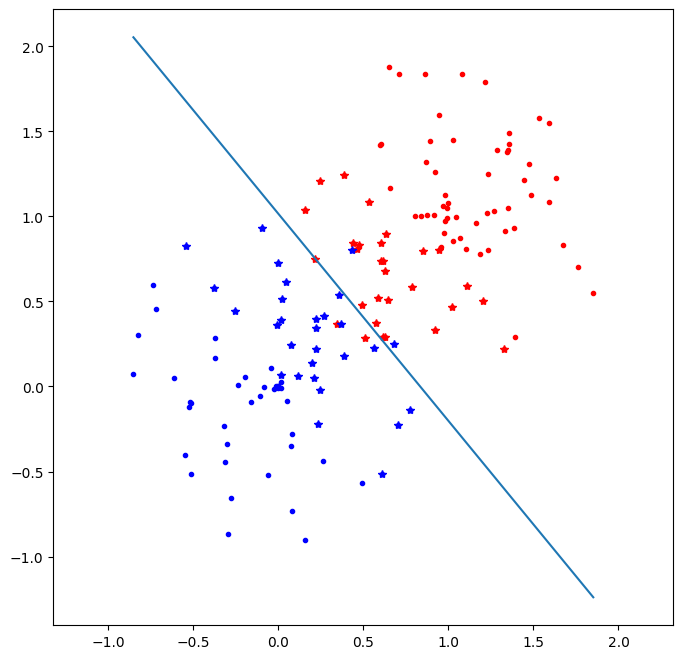

Kernel = linear, C = 1.00, Accuracy: 0.9733
Confusion matrix
[[65  2]
 [ 2 81]]
Support vectors selected: 30


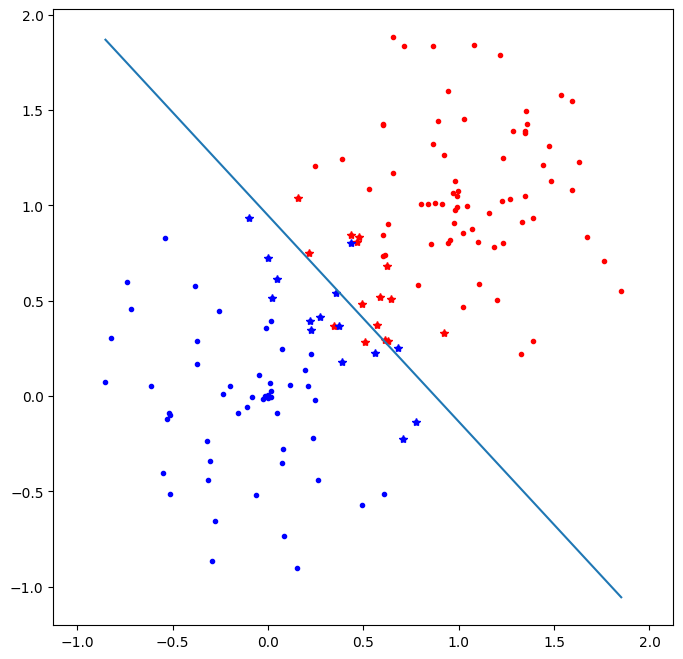

Kernel = linear, C = 10.00, Accuracy: 0.9733
Confusion matrix
[[65  2]
 [ 2 81]]
Support vectors selected: 18


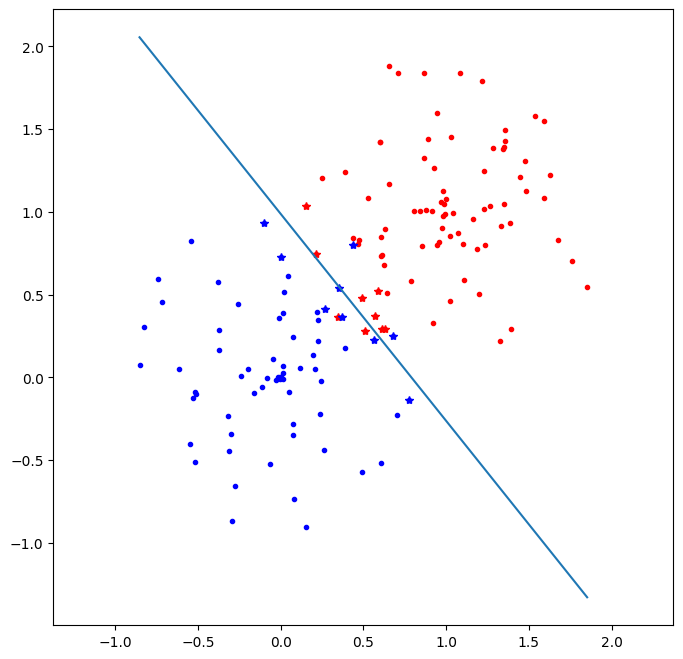

Kernel = linear, C = 100.00, Accuracy: 0.9667
Confusion matrix
[[63  4]
 [ 1 82]]
Support vectors selected: 15


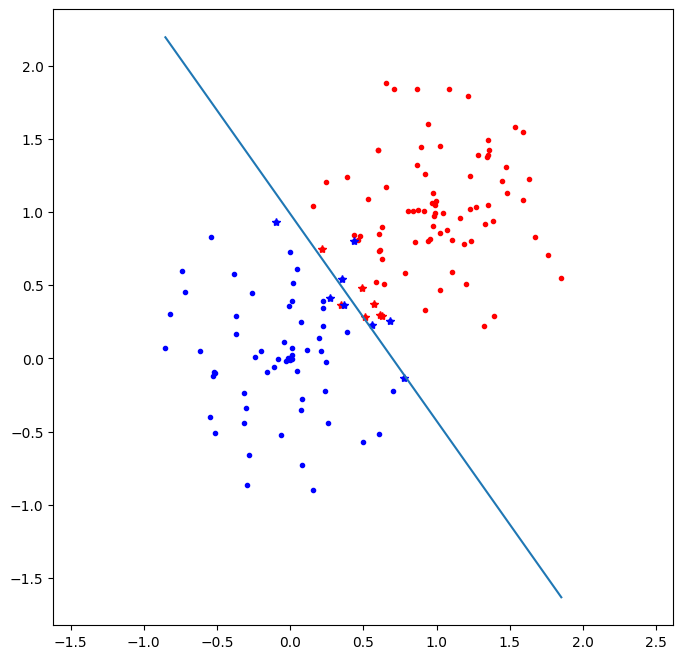

In [10]:
#np.random.seed(0)
n = 150
r = np.random.random(size = (n,1))
t = np.random.random(size = (n,1))*2*np.pi
X = np.hstack((r*np.sin(t),r*np.cos(t)))
y = np.int32(np.random.random(size = (n,))>0.5)
X[y==1] += np.array([1,1])

C = [0.01, 0.1, 1.0, 10.0, 100.0]
kernel ='linear'
for c in C:
  model = SVC(C=c, kernel='linear')
  model.fit(X, y)
  pred = model.predict(X)
  accuracy = accuracy_score(y, pred)
  print('Kernel = {}, C = {:3.2f}, Accuracy: {:6.4f}'.format(kernel,c,accuracy))
  print('Confusion matrix')
  print(confusion_matrix(y, pred))
  print('Support vectors selected:',len(model.support_))
  plot_svm_data(X,y,model)

### Saved Results

| C | Accuracy | Support Vectors |
|---:|---:|---:|
| 0.01 | 0.9600 | 132 |
| 0.10 | 0.9667 | 58 |
| 1.00 | **0.9733** | 30 |
| 10.00 | **0.9733** | 18 |
| 100.00 | 0.9667 | 15 |

For the overlapping sample, increasing `C` reduces the support-vector count, but the highest training accuracy occurs at intermediate values rather than at the largest tested value.

## 8. Inspecting the Dual Coefficients

After the overlapping-data sweep, `model` contains the final linear SVM from the `C=100` case.

`model.dual_coef_` stores the signed support-vector coefficients. The sums of the negative and positive coefficients have equal magnitude and opposite sign.

In [11]:
print(model.dual_coef_)
print(np.sum(model.dual_coef_[model.dual_coef_< 0]))
print(np.sum(model.dual_coef_[model.dual_coef_> 0]))

[[-100.         -100.         -100.          -69.0394412  -100.
  -100.         -100.           -0.35047317  100.          100.
   100.          100.          100.          100.           69.38991437]]
-669.389914365344
669.3899143653439


## 9. Reconstructing the Decision Scores

For a linear kernel, the unthresholded decision score can be reconstructed directly from the signed dual coefficients, support vectors, input matrix, and intercept.

In [12]:
p = np.matmul(model.dual_coef_.reshape(1,-1),np.matmul(X[model.support_],X.T)).reshape(-1)+model.intercept_

### Manual Prediction Threshold

Scores greater than zero are assigned to class 1; the remaining observations are assigned to class 0.

In [13]:
pred = np.zeros_like(y)
pred[p>0] = 1
accuracy = accuracy_score(y, pred)
print('Accuracy: {:6.4f}'.format(accuracy))

Accuracy: 0.9667


The manually reconstructed predictions reproduce the saved model accuracy of **0.9667**.

## 10. Recovering the Weight Vector

The primal weight vector can be recovered by summing each support vector multiplied by its signed dual coefficient. The recovered vector is compared directly with `model.coef_`.

In [14]:
W = np.sum(model.dual_coef_.T*X[model.support_],axis=0)
print(W)
print(model.coef_[0])

[7.35527981 5.20022743]
[7.35527981 5.20022743]


The two vectors match exactly in the saved output:

```text
[7.35527981 5.20022743]
[7.35527981 5.20022743]
```

## 11. Key Findings

- The support-vector count is highly sensitive to the regularization parameter even when classification accuracy is unchanged.
- For separable data, sufficiently large values of `C` recover a compact maximum-margin solution with only three support vectors.
- When classes overlap, larger values of `C` reduce the number of support vectors but do not necessarily improve accuracy.
- Linear SVM predictions can be reconstructed directly from the support vectors, dual coefficients, and intercept.
- The primal coefficient vector can be recovered exactly from the signed dual coefficients and support vectors.